# HW4 Image Restoration — Improved PromptIR Baseline

This notebook keeps the original dataset structure and submission format, but replaces the very small baseline by a stronger PromptIR-inspired restoration pipeline:

- single model for both rain and snow;
- no pretrained weights and no external data;
- PromptIR-style degradation prompts injected in the bottleneck and decoder;
- residual learning: the model predicts a correction added to the degraded input;
- mixed precision, EMA weights, gradient clipping, checkpointing after every epoch;
- stronger restoration losses: L1 + Charbonnier + SSIM + edge loss;
- robust inference with optional test-time augmentation and automatic `pred.npz` creation.

The goal is to give a much more serious baseline than the previous simplified U-Net while staying easy to run on Colab.

In [1]:
# ============================================================
# 1. Setup, imports and global configuration
# ============================================================

import os
import math
import time
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision.transforms.functional as TF

print('PyTorch:', torch.__version__)

PyTorch: 2.10.0+cu128


In [2]:
# ============================================================
# 2. Reproducibility
# ============================================================

SEED = 42

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

In [3]:
# ============================================================
# 3. Paths
# Keep these paths compatible with the structure given in the assignment.
# If the dataset is in the current working directory, keep DATA_ROOT = Path('').
# ============================================================

DATA_ROOT = Path('')  # Change only if your dataset is somewhere else.

TRAIN_DIR = DATA_ROOT / 'train'
TRAIN_DEGRADED_DIR = TRAIN_DIR / 'degraded'
TRAIN_CLEAN_DIR = TRAIN_DIR / 'clean'

TEST_DIR = DATA_ROOT / 'test'
TEST_DEGRADED_DIR = TEST_DIR / 'degraded'

OUTPUT_DIR = Path('')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints_hw4_improved'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / 'best_promptir_improved.pth'
LAST_MODEL_PATH = CHECKPOINT_DIR / 'last_promptir_improved.pth'
PRED_NPZ_PATH = OUTPUT_DIR / 'pred.npz'  # Must be named pred.npz for CodaBench.

print('Train degraded:', TRAIN_DEGRADED_DIR.resolve())
print('Train clean   :', TRAIN_CLEAN_DIR.resolve())
print('Test degraded :', TEST_DEGRADED_DIR.resolve())

Train degraded: C:\Users\titou\Documents\ISEN\M1\Taiwan\Cours\Selected Topic In Visual Recognition Using Deep Learning\HW4\train\degraded
Train clean   : C:\Users\titou\Documents\ISEN\M1\Taiwan\Cours\Selected Topic In Visual Recognition Using Deep Learning\HW4\train\clean
Test degraded : C:\Users\titou\Documents\ISEN\M1\Taiwan\Cours\Selected Topic In Visual Recognition Using Deep Learning\HW4\test\degraded


In [4]:
# ============================================================
# 4. Hyperparameters
# ============================================================

IMG_SIZE = 256         
VAL_SIZE = 256          # Validation uses center crop/resize logic.
BATCH_SIZE = 4          # Reduce to 4 if OOM.
NUM_WORKERS = 0         # Use 0 if Colab/Windows dataloader crashes.
EPOCHS = 40             # For a serious score, use 80-150 if possible.

LR = 2e-4
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.10
GRAD_CLIP_NORM = 1.0
EMA_DECAY = 0.999
USE_AMP = True

# Model size. Increase BASE_CHANNELS to 64 if GPU memory allows.
BASE_CHANNELS = 32
NUM_PROMPTS = 8
NUM_BLOCKS = [2, 3, 4]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [5]:
# ============================================================
# 5. Utility functions
# ============================================================

IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg')

def list_images(folder: Path) -> List[Path]:
    if not folder.exists():
        raise FileNotFoundError(f'Missing folder: {folder}')
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])


def load_rgb_image(path: Path) -> Image.Image:
    return Image.open(path).convert('RGB')


def pil_to_tensor(image: Image.Image) -> torch.Tensor:
    return TF.to_tensor(image)


def tensor_to_uint8_chw(tensor: torch.Tensor) -> np.ndarray:
    tensor = tensor.detach().cpu().clamp(0, 1)
    return (tensor.numpy() * 255.0).round().astype(np.uint8)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_clean_filename(degraded_name: str) -> str:
    if degraded_name.startswith('rain-'):
        return degraded_name.replace('rain-', 'rain_clean-')
    if degraded_name.startswith('snow-'):
        return degraded_name.replace('snow-', 'snow_clean-')
    raise ValueError(f'Unknown training filename: {degraded_name}')

In [6]:
# ============================================================
# 6. Dataset indexing and train/validation split
# ============================================================

train_degraded_images = list_images(TRAIN_DEGRADED_DIR)
train_clean_images = list_images(TRAIN_CLEAN_DIR)
test_images = list_images(TEST_DEGRADED_DIR)

all_pairs = []
for degraded_path in train_degraded_images:
    clean_path = TRAIN_CLEAN_DIR / get_clean_filename(degraded_path.name)
    if clean_path.exists():
        all_pairs.append({
            'degraded_path': degraded_path,
            'clean_path': clean_path,
            'type': 'rain' if degraded_path.name.startswith('rain-') else 'snow',
        })

print('Train degraded images:', len(train_degraded_images))
print('Train clean images   :', len(train_clean_images))
print('Valid train pairs    :', len(all_pairs))
print('Test images          :', len(test_images))

train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=VAL_RATIO,
    random_state=SEED,
    shuffle=True,
    stratify=[s['type'] for s in all_pairs],
)

print('Train samples:', len(train_pairs))
print('Val samples  :', len(val_pairs))

Train degraded images: 3200
Train clean images   : 3200
Valid train pairs    : 3200
Test images          : 100
Train samples: 2880
Val samples  : 320


In [7]:
# ============================================================
# 7. Paired augmentation
# Only paired geometric transforms are applied to both degraded and clean images.
# Mild color jitter is applied only to degraded image with low probability, because
# the target must stay the real clean image.
# ============================================================

class PairedAugmentation:
    def __init__(self, img_size: int, training: bool = True):
        self.img_size = img_size
        self.training = training

    def random_crop(self, degraded: Image.Image, clean: Image.Image) -> Tuple[Image.Image, Image.Image]:
        w, h = degraded.size
        if w < self.img_size or h < self.img_size:
            new_w = max(w, self.img_size)
            new_h = max(h, self.img_size)
            degraded = TF.resize(degraded, [new_h, new_w], antialias=True)
            clean = TF.resize(clean, [new_h, new_w], antialias=True)
            w, h = degraded.size
        top = random.randint(0, h - self.img_size)
        left = random.randint(0, w - self.img_size)
        degraded = TF.crop(degraded, top, left, self.img_size, self.img_size)
        clean = TF.crop(clean, top, left, self.img_size, self.img_size)
        return degraded, clean

    def center_crop_or_resize(self, degraded: Image.Image, clean: Image.Image) -> Tuple[Image.Image, Image.Image]:
        w, h = degraded.size
        if min(w, h) < self.img_size:
            degraded = TF.resize(degraded, [self.img_size, self.img_size], antialias=True)
            clean = TF.resize(clean, [self.img_size, self.img_size], antialias=True)
        else:
            degraded = TF.center_crop(degraded, [self.img_size, self.img_size])
            clean = TF.center_crop(clean, [self.img_size, self.img_size])
        return degraded, clean

    def __call__(self, degraded: Image.Image, clean: Image.Image) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.training:
            degraded, clean = self.random_crop(degraded, clean)
            if random.random() < 0.5:
                degraded = TF.hflip(degraded); clean = TF.hflip(clean)
            if random.random() < 0.5:
                degraded = TF.vflip(degraded); clean = TF.vflip(clean)
            if random.random() < 0.75:
                k = random.randint(0, 3)
                if k:
                    degraded = TF.rotate(degraded, angle=90 * k)
                    clean = TF.rotate(clean, angle=90 * k)
        else:
            degraded, clean = self.center_crop_or_resize(degraded, clean)
        return pil_to_tensor(degraded), pil_to_tensor(clean)


class RestorationDataset(Dataset):
    def __init__(self, samples: List[Dict], transform: Optional[PairedAugmentation] = None):
        self.samples = samples
        self.transform = transform

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        sample = self.samples[idx]
        degraded = load_rgb_image(sample['degraded_path'])
        clean = load_rgb_image(sample['clean_path'])
        if self.transform is not None:
            degraded, clean = self.transform(degraded, clean)
        else:
            degraded, clean = pil_to_tensor(degraded), pil_to_tensor(clean)
        return {'degraded': degraded, 'clean': clean, 'type': sample['type']}


train_dataset = RestorationDataset(train_pairs, PairedAugmentation(IMG_SIZE, training=True))
val_dataset = RestorationDataset(val_pairs, PairedAugmentation(VAL_SIZE, training=False))

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=False,
)

batch = next(iter(train_loader))
print(batch['degraded'].shape, batch['clean'].shape)

torch.Size([4, 3, 256, 256]) torch.Size([4, 3, 256, 256])


In [8]:
# ============================================================
# 8. PromptIR-inspired model
# This is not pretrained. It is trained from scratch.
# Main improvements over the first baseline:
# - residual output prediction;
# - depthwise feed-forward blocks;
# - channel attention;
# - multi-prompt degradation conditioning;
# - prompts injected at bottleneck and decoder levels.
# ============================================================

class LayerNorm2d(nn.Module):
    def __init__(self, channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(1, channels, 1, 1))
        self.bias = nn.Parameter(torch.zeros(1, channels, 1, 1))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=1, keepdim=True)
        return (x - mean) / torch.sqrt(var + self.eps) * self.weight + self.bias


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.GELU(),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.net(x)


class GatedDWFFN(nn.Module):
    def __init__(self, channels: int, expansion: float = 2.0):
        super().__init__()
        hidden = int(channels * expansion)
        self.project_in = nn.Conv2d(channels, hidden * 2, 1)
        self.dwconv = nn.Conv2d(hidden * 2, hidden * 2, 3, padding=1, groups=hidden * 2)
        self.project_out = nn.Conv2d(hidden, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.project_in(x)
        x1, x2 = self.dwconv(x).chunk(2, dim=1)
        return self.project_out(F.gelu(x1) * x2)


class RestorationBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.norm1 = LayerNorm2d(channels)
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels),
            nn.Conv2d(channels, channels, 1),
            nn.GELU(),
            ChannelAttention(channels),
        )
        self.norm2 = LayerNorm2d(channels)
        self.ffn = GatedDWFFN(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.conv(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class PromptBlock(nn.Module):
    def __init__(self, channels: int, num_prompts: int = 8):
        super().__init__()
        self.prompts = nn.Parameter(torch.randn(num_prompts, channels, 1, 1) * 0.02)
        self.selector = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 2, 1),
            nn.GELU(),
            nn.Conv2d(channels // 2, num_prompts, 1),
            nn.Softmax(dim=1),
        )
        self.fusion = nn.Sequential(
            nn.Conv2d(channels * 2, channels, 1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        weights = self.selector(x).unsqueeze(2)
        prompts = self.prompts.unsqueeze(0)
        prompt = (weights * prompts).sum(dim=1).expand(b, c, h, w)
        return x + self.fusion(torch.cat([x, prompt], dim=1))


def make_stage(channels: int, depth: int) -> nn.Sequential:
    return nn.Sequential(*[RestorationBlock(channels) for _ in range(depth)])


class ImprovedPromptIR(nn.Module):
    def __init__(self, base_channels: int = 56, num_prompts: int = 8, blocks: List[int] = [2, 3, 4]):
        super().__init__()
        c1, c2, c3 = base_channels, base_channels * 2, base_channels * 4
        self.intro = nn.Conv2d(3, c1, 3, padding=1)
        self.enc1 = make_stage(c1, blocks[0])
        self.down1 = nn.Conv2d(c1, c2, 3, stride=2, padding=1)
        self.enc2 = make_stage(c2, blocks[1])
        self.down2 = nn.Conv2d(c2, c3, 3, stride=2, padding=1)
        self.bottleneck = nn.Sequential(
            make_stage(c3, blocks[2]),
            PromptBlock(c3, num_prompts),
            make_stage(c3, blocks[2]),
        )
        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.prompt2 = PromptBlock(c2, num_prompts)
        self.dec2 = make_stage(c2, blocks[1])
        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.prompt1 = PromptBlock(c1, num_prompts)
        self.dec1 = make_stage(c1, blocks[0])
        self.outro = nn.Conv2d(c1, 3, 3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        inp = x
        x1 = self.enc1(self.intro(x))
        x2 = self.enc2(self.down1(x1))
        x3 = self.bottleneck(self.down2(x2))
        y2 = self.up2(x3)
        if y2.shape[-2:] != x2.shape[-2:]:
            y2 = F.interpolate(y2, size=x2.shape[-2:], mode='bilinear', align_corners=False)
        y2 = self.dec2(self.prompt2(y2 + x2))
        y1 = self.up1(y2)
        if y1.shape[-2:] != x1.shape[-2:]:
            y1 = F.interpolate(y1, size=x1.shape[-2:], mode='bilinear', align_corners=False)
        y1 = self.dec1(self.prompt1(y1 + x1))
        residual = self.outro(y1)
        return (inp + residual).clamp(0, 1)


model = ImprovedPromptIR(
    base_channels=BASE_CHANNELS,
    num_prompts=NUM_PROMPTS,
    blocks=NUM_BLOCKS,
).to(DEVICE)

print(model.__class__.__name__)
print('Trainable parameters:', f'{count_parameters(model):,}')
with torch.no_grad():
    x = batch['degraded'][:1].to(DEVICE)
    y = model(x)
print('Forward test:', x.shape, '->', y.shape, y.min().item(), y.max().item())

ImprovedPromptIR
Trainable parameters: 1,638,811
Forward test: torch.Size([1, 3, 256, 256]) -> torch.Size([1, 3, 256, 256]) 0.0 1.0


In [9]:
# ============================================================
# 9. Losses and metrics
# ============================================================

class CharbonnierLoss(nn.Module):
    def __init__(self, eps: float = 1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return torch.mean(torch.sqrt((pred - target) ** 2 + self.eps ** 2))


def ssim_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mu_x = F.avg_pool2d(pred, 3, 1, 1)
    mu_y = F.avg_pool2d(target, 3, 1, 1)
    sigma_x = F.avg_pool2d(pred * pred, 3, 1, 1) - mu_x * mu_x
    sigma_y = F.avg_pool2d(target * target, 3, 1, 1) - mu_y * mu_y
    sigma_xy = F.avg_pool2d(pred * target, 3, 1, 1) - mu_x * mu_y
    ssim = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (sigma_x + sigma_y + c2) + 1e-8)
    return 1.0 - ssim.mean()


def gradient_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return F.l1_loss(pred_dx, target_dx) + F.l1_loss(pred_dy, target_dy)


def restoration_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # Weights are chosen to optimize PSNR while preserving structure.
    l1 = F.l1_loss(pred, target)
    charb = charbonnier(pred, target)
    ssim = ssim_loss(pred, target)
    edge = gradient_loss(pred, target)
    return l1 + 0.5 * charb + 0.15 * ssim + 0.05 * edge


def compute_psnr(pred: torch.Tensor, target: torch.Tensor, max_value: float = 1.0) -> torch.Tensor:
    mse = F.mse_loss(pred.clamp(0, 1), target, reduction='none').mean(dim=(1, 2, 3))
    return 10.0 * torch.log10((max_value ** 2) / (mse + 1e-8)).mean()

charbonnier = CharbonnierLoss()

In [10]:
# ============================================================
# 10. Optimizer, scheduler, AMP and EMA
# ============================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.99))
num_training_steps = EPOCHS * len(train_loader)
warmup_steps = max(10, int(0.05 * num_training_steps))

def lr_lambda(step: int) -> float:
    if step < warmup_steps:
        return float(step + 1) / float(warmup_steps)
    progress = (step - warmup_steps) / max(1, num_training_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE.type == 'cuda')

class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items() if v.dtype.is_floating_point}
        self.backup = {}

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)

    def apply_shadow(self, model: nn.Module) -> None:
        self.backup = {}
        state = model.state_dict()
        for k in self.shadow:
            self.backup[k] = state[k].detach().clone()
            state[k].copy_(self.shadow[k])

    def restore(self, model: nn.Module) -> None:
        state = model.state_dict()
        for k, v in self.backup.items():
            state[k].copy_(v)
        self.backup = {}

ema = EMA(model, decay=EMA_DECAY)

C:\Users\titou\AppData\Local\Temp\ipykernel_27844\1340019689.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE.type == 'cuda')


In [11]:
# ============================================================
# 11. Training and validation functions
# ============================================================

def train_one_epoch(epoch: int) -> Tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_psnr = 0.0
    progress = tqdm(train_loader, desc=f'Epoch {epoch} training', leave=False)

    for batch in progress:
        degraded = batch['degraded'].to(DEVICE, non_blocking=True)
        clean = batch['clean'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP and DEVICE.type == 'cuda'):
            restored = model(degraded)
            loss = restoration_loss(restored, clean)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)

        with torch.no_grad():
            psnr = compute_psnr(restored, clean)
        total_loss += loss.item()
        total_psnr += psnr.item()
        progress.set_postfix(loss=f'{loss.item():.4f}', psnr=f'{psnr.item():.2f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}')

    return total_loss / len(train_loader), total_psnr / len(train_loader)


@torch.no_grad()
def validate(use_ema: bool = True) -> Tuple[float, float]:
    if use_ema:
        ema.apply_shadow(model)
    model.eval()
    total_loss = 0.0
    total_psnr = 0.0
    progress = tqdm(val_loader, desc='Validation', leave=False)
    for batch in progress:
        degraded = batch['degraded'].to(DEVICE, non_blocking=True)
        clean = batch['clean'].to(DEVICE, non_blocking=True)
        restored = model(degraded)
        loss = restoration_loss(restored, clean)
        psnr = compute_psnr(restored, clean)
        total_loss += loss.item()
        total_psnr += psnr.item()
        progress.set_postfix(val_psnr=f'{psnr.item():.2f}')
    if use_ema:
        ema.restore(model)
    return total_loss / len(val_loader), total_psnr / len(val_loader)

In [12]:
# ============================================================
# 12. Full training loop with best checkpoint saving
# ============================================================

history = {'train_loss': [], 'train_psnr': [], 'val_loss': [], 'val_psnr': [], 'lr': []}
best_val_psnr = -float('inf')
start_training_time = time.time()

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_psnr = train_one_epoch(epoch)
    val_loss, val_psnr = validate(use_ema=True)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_psnr'].append(train_psnr)
    history['val_loss'].append(val_loss)
    history['val_psnr'].append(val_psnr)
    history['lr'].append(current_lr)

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'ema_shadow': ema.shadow,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_psnr': max(best_val_psnr, val_psnr),
        'history': history,
        'config': {
            'img_size': IMG_SIZE,
            'base_channels': BASE_CHANNELS,
            'num_prompts': NUM_PROMPTS,
            'num_blocks': NUM_BLOCKS,
        },
    }
    torch.save(checkpoint, LAST_MODEL_PATH)

    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr
        torch.save(checkpoint, BEST_MODEL_PATH)
        print('Saved new best checkpoint.')

    elapsed = time.time() - start
    print(f'Epoch {epoch:03d}/{EPOCHS} | train_loss={train_loss:.4f} | train_psnr={train_psnr:.2f} | val_loss={val_loss:.4f} | val_psnr={val_psnr:.2f} | lr={current_lr:.2e} | time={elapsed/60:.1f} min')

print('Best validation PSNR:', best_val_psnr)
print('Total training time:', (time.time() - start_training_time) / 60, 'min')

Epoch 1 training:   0%|          | 0/720 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]

Saved new best checkpoint.
Epoch 001/40 | train_loss=0.2541 | train_psnr=17.43 | val_loss=0.2976 | val_psnr=15.67 | lr=1.00e-04 | time=4.0 min


Epoch 2 training:   0%|          | 0/720 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/80 [00:00<?, ?it/s]

Saved new best checkpoint.
Epoch 039/40 | train_loss=0.0676 | train_psnr=27.30 | val_loss=0.0645 | val_psnr=27.64 | lr=3.42e-07 | time=3.4 min


Epoch 40 training:   0%|          | 0/720 [00:00<?, ?it/s]

Validation:   0%|          | 0/80 [00:00<?, ?it/s]

Saved new best checkpoint.
Epoch 040/40 | train_loss=0.0675 | train_psnr=27.31 | val_loss=0.0645 | val_psnr=27.64 | lr=0.00e+00 | time=3.4 min
Best validation PSNR: 27.637202620506287
Total training time: 138.22475129763285 min


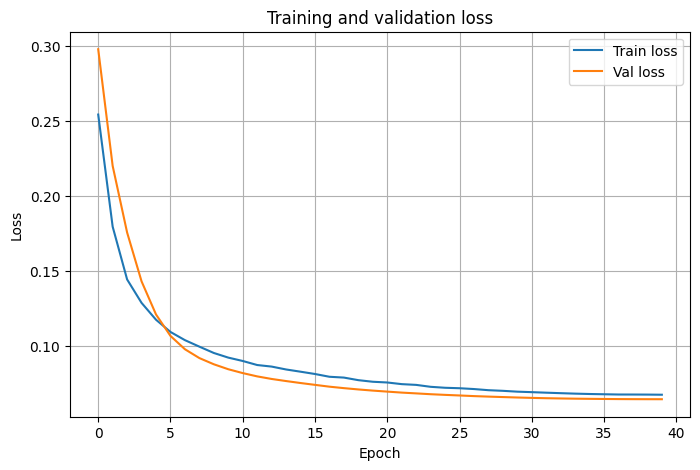

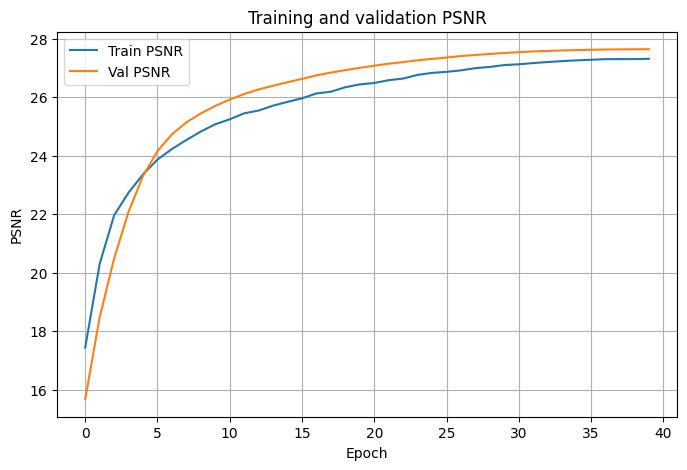

In [13]:
# ============================================================
# 13. Training curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['train_psnr'], label='Train PSNR')
plt.plot(history['val_psnr'], label='Val PSNR')
plt.xlabel('Epoch')
plt.ylabel('PSNR')
plt.title('Training and validation PSNR')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# ============================================================
# 14. Load best EMA checkpoint before inference
# ============================================================

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
if 'ema_shadow' in checkpoint:
    state = model.state_dict()
    for k, v in checkpoint['ema_shadow'].items():
        if k in state:
            state[k].copy_(v)
model.to(DEVICE).eval()
print('Loaded:', BEST_MODEL_PATH)
print('Best validation PSNR:', checkpoint.get('best_val_psnr'))

Loaded: checkpoints_hw4_improved\best_promptir_improved.pth
Best validation PSNR: 27.637202620506287


In [15]:
# ============================================================
# 15. Test dataset and TTA inference
# Submission format: pred.npz with keys '0.png'...'99.png' and arrays (3,H,W) uint8.
# ============================================================

class TestRestorationDataset(Dataset):
    def __init__(self, image_dir: Path):
        self.image_paths = list_images(image_dir)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        path = self.image_paths[idx]
        image = load_rgb_image(path)
        return {'degraded': pil_to_tensor(image), 'filename': path.name, 'size': image.size}


def augment_x8(x: torch.Tensor) -> List[torch.Tensor]:
    return [
        x,
        torch.flip(x, dims=[-1]),
        torch.flip(x, dims=[-2]),
        torch.flip(x, dims=[-2, -1]),
        torch.rot90(x, 1, dims=[-2, -1]),
        torch.rot90(x, 2, dims=[-2, -1]),
        torch.rot90(x, 3, dims=[-2, -1]),
        torch.flip(torch.rot90(x, 1, dims=[-2, -1]), dims=[-1]),
    ]


def deaugment_x8(outputs: List[torch.Tensor]) -> List[torch.Tensor]:
    return [
        outputs[0],
        torch.flip(outputs[1], dims=[-1]),
        torch.flip(outputs[2], dims=[-2]),
        torch.flip(outputs[3], dims=[-2, -1]),
        torch.rot90(outputs[4], -1, dims=[-2, -1]),
        torch.rot90(outputs[5], -2, dims=[-2, -1]),
        torch.rot90(outputs[6], -3, dims=[-2, -1]),
        torch.rot90(torch.flip(outputs[7], dims=[-1]), -1, dims=[-2, -1]),
    ]


@torch.no_grad()
def predict_with_tta(x: torch.Tensor, use_tta: bool = True) -> torch.Tensor:
    if not use_tta:
        return model(x).clamp(0, 1)
    augmented = augment_x8(x)
    outputs = [model(a).clamp(0, 1) for a in augmented]
    outputs = deaugment_x8(outputs)
    return torch.stack(outputs, dim=0).mean(dim=0).clamp(0, 1)


test_dataset = TestRestorationDataset(TEST_DEGRADED_DIR)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)
print('Test images:', len(test_dataset))

Test images: 100


In [16]:
# ============================================================
# 16. Generate pred.npz
# ============================================================

USE_TTA_INFERENCE = True  # x8 TTA is slower but usually improves leaderboard PSNR.
predictions = {}

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Inference'):
        degraded = batch['degraded'].to(DEVICE)
        filename = batch['filename'][0]
        restored = predict_with_tta(degraded, use_tta=USE_TTA_INFERENCE).squeeze(0)
        predictions[filename] = tensor_to_uint8_chw(restored)

# Save exactly as requested by CodaBench.
np.savez(PRED_NPZ_PATH, **predictions)
print(f'Saved {len(predictions)} predictions to {PRED_NPZ_PATH.resolve()}')

Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 predictions to C:\Users\titou\Documents\ISEN\M1\Taiwan\Cours\Selected Topic In Visual Recognition Using Deep Learning\HW4\pred.npz


In [17]:
# ============================================================
# 17. Strict submission validation
# ============================================================

loaded = np.load(PRED_NPZ_PATH)
expected_keys = [f'{i}.png' for i in range(100)]
actual_keys = sorted(loaded.files, key=lambda x: int(x.split('.')[0]))

print('Number of predictions:', len(actual_keys))
print('First keys:', actual_keys[:5])
print('Last keys :', actual_keys[-5:])

missing = sorted(set(expected_keys) - set(actual_keys), key=lambda x: int(x.split('.')[0]))
extra = sorted(set(actual_keys) - set(expected_keys))
print('Missing keys:', missing)
print('Extra keys:', extra)

all_valid = True
for key in expected_keys:
    if key not in loaded:
        all_valid = False
        continue
    arr = loaded[key]
    if arr.ndim != 3 or arr.shape[0] != 3:
        print('Wrong shape:', key, arr.shape)
        all_valid = False
    if arr.dtype != np.uint8:
        print('Wrong dtype:', key, arr.dtype)
        all_valid = False
    if arr.min() < 0 or arr.max() > 255:
        print('Wrong range:', key, arr.min(), arr.max())
        all_valid = False

print('pred.npz is valid.' if all_valid else 'pred.npz has errors.')

Number of predictions: 100
First keys: ['0.png', '1.png', '2.png', '3.png', '4.png']
Last keys : ['95.png', '96.png', '97.png', '98.png', '99.png']
Missing keys: []
Extra keys: []
pred.npz is valid.


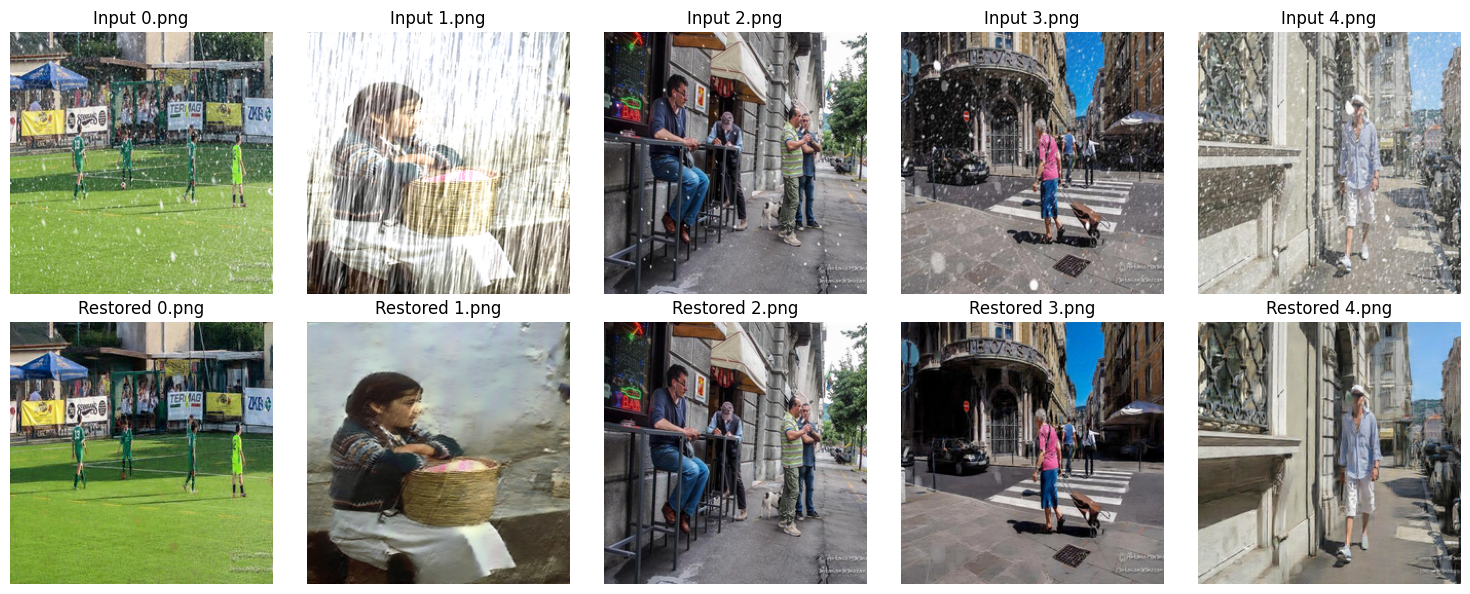

In [18]:
# ============================================================
# 18. Visual check
# ============================================================

def chw_to_hwc(image_chw: np.ndarray) -> np.ndarray:
    return np.transpose(image_chw, (1, 2, 0))

loaded_preds = np.load(PRED_NPZ_PATH)
sample_keys = sorted(loaded_preds.files, key=lambda x: int(x.split('.')[0]))[:5]

plt.figure(figsize=(15, 6))
for i, key in enumerate(sample_keys):
    degraded_img = np.array(load_rgb_image(TEST_DEGRADED_DIR / key))
    restored_img = chw_to_hwc(loaded_preds[key])
    plt.subplot(2, len(sample_keys), i + 1)
    plt.imshow(degraded_img)
    plt.title(f'Input {key}')
    plt.axis('off')
    plt.subplot(2, len(sample_keys), i + 1 + len(sample_keys))
    plt.imshow(restored_img)
    plt.title(f'Restored {key}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Practical notes to push PSNR higher

For a quick run, keep `IMG_SIZE=192`, `BASE_CHANNELS=56`, and `EPOCHS=80`. If the GPU allows it, the best next changes are usually `IMG_SIZE=224` or `256`, `BASE_CHANNELS=64`, and `EPOCHS=120-150`. Keep `pred.npz` exactly at the project root or zip only this file for CodaBench.

If validation PSNR is much higher than CodaBench, the issue is usually submission format or using a bad checkpoint. This notebook saves the file as `pred.npz`, stores arrays as `uint8` with shape `(3,H,W)`, and loads EMA weights before inference.